## 8. K-Nearest Neighbor (KNN)

In [2]:
#!pip install pyod
#!pip install combo

In [1]:
######################
# Helper functions
######################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyod.utils.data import generate_data

def DGP(
    contamination=0.05,
    n_train=500,
    n_test=500,
    n_features=6,
    random_state=123,
    shift=True,
    return_df=True
):
    """
    Data Generating Process (DGP) for anomaly detection examples.

    Parameters
    ----------
    contamination : float
        Percentage of outliers
    n_train : int
        Number of training samples
    n_test : int
        Number of test samples
    n_features : int
        Number of features
    random_state : int
        Seed for reproducibility
    shift : bool
        Apply transformation (e.g., 5 - X)
    return_df : bool
        Return pandas DataFrame if True

    Returns
    -------
    X_train, X_test, y_train, y_test
    """

    X_train, X_test, y_train, y_test = generate_data(
        n_train=n_train,
        n_test=n_test,
        n_features=n_features,
        contamination=contamination,
        random_state=random_state
    )

    X_train = 5 - X_train
    X_test = 5 - X_test

    if return_df:
        X_train = pd.DataFrame(X_train)
        X_test = pd.DataFrame(X_test)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = DGP(
    contamination=0.05,
    n_train=500,
    n_test=500,
    n_features=6,
    random_state=123,
    shift=True,
    return_df=True
)

def plot_generated_data(x1,x2,y_train):
    # Plot
    plt.scatter(x1, x2, c=y_train, alpha=0.8)
    plt.title('Scatter plot')
    plt.xlabel('x0')
    plt.ylabel('x1')
    plt.show()

def evaluate_model(model, X_train, X_test):
    """
    Generate scores, predictions, and threshold for train and test data.

    Parameters
    ----------
    model : trained model
    X_train : array-like
    X_test : array-like

    Returns
    -------
    results : dict
        Contains scores, 
        predictions, and 
        threshold
    """

    results = {
        "train_scores": model.decision_function(X_train),
        "train_pred": model.predict(X_train),
        "test_scores": model.decision_function(X_test),
        "test_pred": model.predict(X_test),
        "threshold": getattr(model, "threshold_", None)
    }

    return results

def count_stat(vector):
    # Because it is '0' and '1', we can run a count statistic.
    unique, counts = np.unique(vector, return_counts=True)
    return dict(zip(unique, counts))

def plot_hist(scores, title="Outlier Score"):
    """
    Plot histogram of outlier scores.

    Parameters
    ----------
    scores : array-like
        Outlier scores
    title : str
        Title of the plot
    """

    plt.hist(scores, bins='auto')
    plt.title(title)
    plt.show()

def descriptive_stat_threshold(X, scores, threshold, feature_names=None):
    """
    Generate descriptive statistics for normal and outlier groups.

    Parameters
    ----------
    X : array-like
        Input data
    scores : array-like
        Outlier scores
    threshold : float
        Threshold to classify outliers
    feature_names : list, optional
        Feature names for labeling columns

    Returns
    -------
    summary : DataFrame
        Count, percentage, and mean statistics by group
    """

    df = pd.DataFrame(X)

    # Assign feature names if provided
    if feature_names:
        df.columns = feature_names

    # Add score and group label
    df["Anomaly_Score"] = scores
    df["Group"] = np.where(df["Anomaly_Score"] < threshold, "Normal", "Outlier")

    # Count and percentage
    count = (
        df.groupby("Group")["Anomaly_Score"]
        .count()
        .reset_index()
        .rename(columns={"Anomaly_Score": "Count"})
    )
    count["Count %"] = count["Count"] / count["Count"].sum() * 100

    # Mean statistics
    stats = (
        df.groupby("Group")
        .mean(numeric_only=True)
        .round(2)
        .reset_index()
    )

    # Merge results
    summary = count.merge(stats, on="Group")

    return summary

def confusion_matrix(actual, scores, threshold):
    """
    Create a confusion matrix using actual labels and outlier scores.

    Parameters
    ----------
    actual : array-like
        True labels (0 = normal, 1 = outlier)
    scores : array-like
        Outlier scores
    threshold : float
        Threshold to classify outliers

    Returns
    -------
    cm : DataFrame
        Confusion matrix
    """

    df = pd.DataFrame({
        "Actual": actual,
        "Score": scores
    })

    # Convert scores to predicted labels
    df["Pred"] = np.where(df["Score"] <= threshold, 0, 1)

    # Generate confusion matrix
    cm = pd.crosstab(df["Actual"], df["Pred"])

    return cm

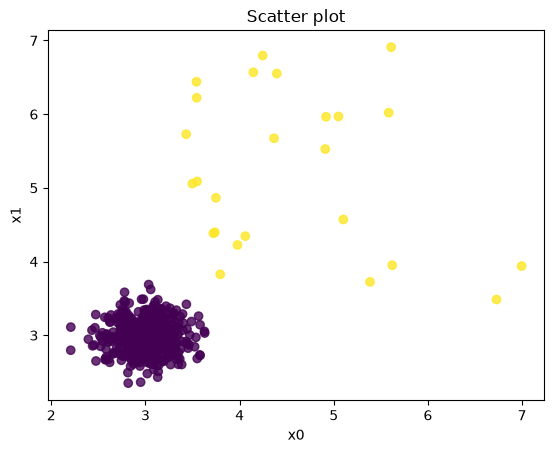

In [2]:
X_train, X_test, y_train, y_test = DGP(
    contamination=0.05,
    n_train=500,
    n_test=500,
    n_features=6,
    random_state=123,
    shift=True,
    return_df=True
)
plot_generated_data(X_train[0],X_train[1],y_train)

### Step 1: Build the model

In [3]:
# train kNN detector
from pyod.models.knn import KNN
knn = KNN()
knn.fit(X_train)

,contamination,0.1
,n_neighbors,5
,method,'largest'
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,n_jobs,1
Name,Type,Value


In [4]:
results = evaluate_model(knn, X_train, X_test)
y_train_scores = results["train_scores"]
y_train_pred = results["train_pred"]

y_test_scores = results["test_scores"]
y_test_pred = results["test_pred"]
threshold = results["threshold"]

In [5]:
knn.get_params()

{'algorithm': 'auto',
 'contamination': 0.1,
 'leaf_size': 30,
 'method': 'largest',
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': 1,
 'n_neighbors': 5,
 'p': 2,
 'radius': 1.0}

### Step 2: Determine the threshold

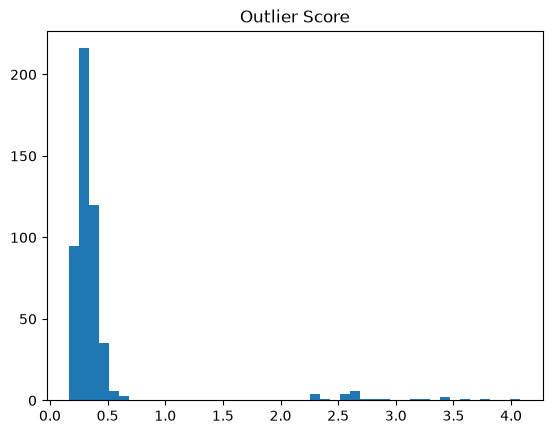

In [6]:
plot_hist(y_train_scores)

### Step 3: Descriptive statistics

In [7]:
feature_list = ['F1','F2','F3','F4','F4','F5']
descriptive_stat_threshold(X_train,y_train_scores, threshold, feature_list)

,Group,Count,Count %,F1,F2,F3,F4,F4,F5,Anomaly_Score
0,Normal,456,91.2,3.00,2.99,2.99,3.01,2.99,3.01,0.31
1,Outlier,44,8.8,3.89,4.24,4.43,4.28,4.18,4.20,1.84


In [8]:
confusion_matrix(y_train, y_train_scores, threshold)

Pred,0,1
Actual,,
0.0,456,19
1.0,0,25


### Averages

In [9]:
from pyod.models.combination import aom, moa, average, maximization
from pyod.utils.utility import standardizer
# Standardize data
X_train_norm, X_test_norm = standardizer(X_train, X_test)
# Test a range of k-neighbors from 10 to 200. There will be 20 k-NN models.
k_list = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110,
 120, 130, 140, 150, 160, 170, 180, 190, 200]
n_clf = len(k_list)
# Just prepare data frames so we can store the model results
train_scores = np.zeros([X_train.shape[0], n_clf])
test_scores = np.zeros([X_test.shape[0], n_clf])
train_scores.shape
# Modeling
for i in range(n_clf):
    k = k_list[i]
    clf = KNN(n_neighbors=k, method='largest')
    clf.fit(X_train_norm)

    # Store the results in each column:
    train_scores[:, i] = clf.decision_scores_
    test_scores[:, i] = clf.decision_function(X_test_norm)
# Decision scores have to be normalized before combination
train_scores_norm, test_scores_norm = standardizer(train_scores,test_scores)

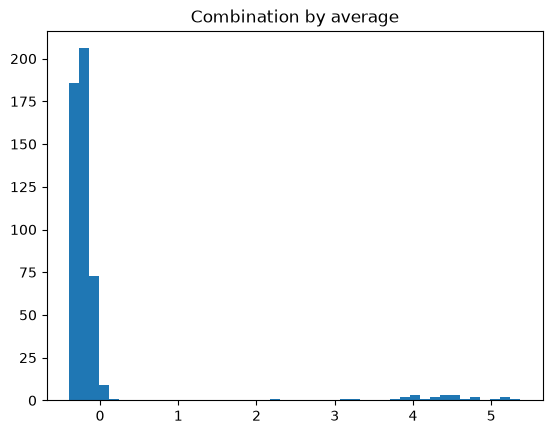

In [10]:
# Combination by average
# The test_scores_norm is 500 x 10. The "average" function will take the average of the 10 columns.
# The result "y_by_average" is a single column:
y_train_by_average = average(train_scores_norm)
y_test_by_average = average(test_scores_norm)

plot_hist(y_train_by_average, title="Combination by average")

In [11]:
descriptive_stat_threshold(X_train,y_train_scores, threshold, feature_list)

,Group,Count,Count %,F1,F2,F3,F4,F4,F5,Anomaly_Score
0,Normal,456,91.2,3.00,2.99,2.99,3.01,2.99,3.01,0.31
1,Outlier,44,8.8,3.89,4.24,4.43,4.28,4.18,4.20,1.84


In [12]:
descriptive_stat_threshold(X_test,y_test_scores, threshold, feature_list)

,Group,Count,Count %,F1,F2,F3,F4,F4,F5,Anomaly_Score
0,Normal,448,89.6,2.99,2.98,3.00,3.01,2.99,3.0,0.33
1,Outlier,52,10.4,3.93,4.24,4.02,4.00,4.00,3.9,1.67
